<a href="https://colab.research.google.com/github/DrakeJay/DrakeJay.github.io/blob/main/Drake_1_Linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear regression
Suppose there are $m$ data points, each with $n$ predictors (known features) and $t$ targets (unknown features in the test set).

Store the predictors in the matrix $X$, which is an $m \times n$ matrix, with each row corresponding to one data point.

Store the targets in the matrix $Y$, which is an $m \times t$ matrix, corresponding to $X$ (i.e., the rows of $X$ and $Y$ are one-to-one mapped).

In the lecture, we only consider a single target variable. Here $Y$ consists of $t$ target variables. The closed form solution is the same as we had derived in this [video](https://oakland.hosted.panopto.com/Panopto/Pages/Viewer.aspx?id=01a9d556-4e95-4079-b028-ad980025411a).

Mathematically, linear regression solves this optimization problem:

Given $X$ and $Y$, find the best $W$ and $b$ such that

$$Y \approx XW + b$$

Linear regression then solves this optimization problem:

$$W^*, b^* = \underset{W, b}{\operatorname{argmin}} ||Y - (XW + b)||^{2}$$

Here, $W$ is a $n \times t$ weight matrix, $b$ is a bias vector of length $t$.

Now let's use a trick to absort $b$ into $W$.

Let $X_{extend}=[X, \bf{1}]$, i.e., append a column of 1 to the last column of $X$. Here $\bf{1}$$=[1,1,\cdots,1]^T$ is  a column vector of length $m$ with every element being 1.


\begin{equation*}
W_{extend} =
\begin{bmatrix}
W \\
b
\end{bmatrix}
\end{equation*}

Now $W^*_{extend}$ is a $(n+1) \times t$ matrix, with the first $n$ row corresponding to $W^*$ and the last row $b^*$.

For your information, the closed form solution with linear regression is

$$W^*_{extend}=(X^{T}_{extend}X_{extend})^{-1}X^{T}_{extend}Y$$

You can then read out $W^*, b^*$ directly from $W^*_{extend}$

In [ ]:
import numpy as np

import matplotlib.pyplot as plt

In [ ]:
def linear_regression_params(X, Y):
    """Given a set of data points stored in X and Y, find the best weight matrix and bias

    Arguments:
        X: 2D numpy array with shape (num_points, num_features)
        Y: 2D numpy array with shape (num_points, num_targets)

    Returns:
        W: 2D numpy array with shape (num_features, num_targets)
        b: b is a 1D numpy array with shape (num_targets,)
    """
    W = None
    b = None
    ################################################################################
    ######################### Write your code in this block (20 points) ############
    ## 20 points ##
    # *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

    #####
    # X is (m , n)
    # Y is (m , t)

    m, n = X.shape
    t = Y.shape[1]

    Ones = np.ones((m, 1))
    Xext = np.hstack((X, Ones))

    #Using the closed-form solution and Xext to find the weights
    # closed form form being W_extend = (X_extend.T @ X_extend)^-1 @ X_extend.T @ Y
    Wext = np.linalg.inv(Xext.T @ Xext) @ Xext.T @ Y

    # Extract W and b from the extended weight matrix
    W = Wext[:-1, :]
    b = Wext[-1, :]

    # *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
    return W, b


def linear_regression_predict(W, b, X_test):
    """Given weight matrix W and bias vector b (b can be None), predict the target matrix for X_test

    Arguments:
        W: 2D numpy array with shape (num_features, num_targets)
        b: b can be a 1D numpy array with shape (num_targets,) or b is None
        X_test: 2D numpy array with shape (num_points, num_features)

    Returns:
        Y_test: 2D numpy array with shape (num_points, num_targets)

    """
    Y_test = None
    ################################################################################
    ######################### Write your code in this block (5 points) #############
    ## 5 points ##
    # *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

    Y_test = X_test @ W + b

    # *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
    return Y_test

# Evaluate your implementation
After you have implemented the above two functions: linear_regression_params and linear_regression_predict
Use the following code to evaluate your implementation.

In [ ]:
def generate_evaluation_data(num_features, num_targets, noise_level=1):
    w_true = np.random.uniform(-5, 5, (num_features, num_targets))
    b_true = np.random.uniform(-10, 10, (num_targets,))

    x_train = np.random.uniform(1, 10, (100, num_features))
    y_train = x_train.dot(w_true) + b_true
    noise = np.random.randn(*y_train.shape) * noise_level
    y_train += noise

    x_test = np.random.uniform(1, 10, (200, num_features))
    y_test = x_test.dot(w_true) + b_true

    return (x_train, y_train), (x_test, y_test), (w_true, b_true)

num_features = 1, num_targets = 1


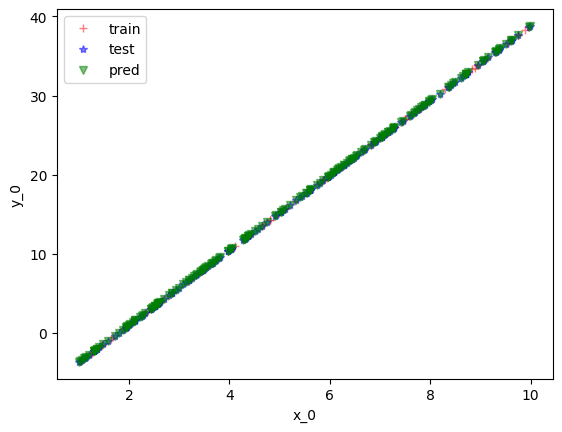

True parameters: w_true=[[4.73254202]], b_true=[-8.50105609]
Learned parameters: w=[[4.73185696]], b=[-8.4986681]
The distance between w_true and w: 0.0006850629902750427
The distance between b_true and b: 0.0023879947860017126
The distance between y_pred and y_test: 0.029775063904949623


num_features = 10, num_targets = 1


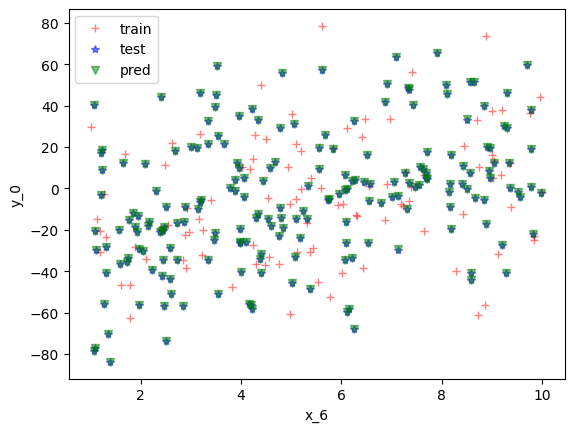

True parameters: w_true=[[-0.38294848]
 [ 4.1612354 ]
 [-4.39429774]
 [-4.8933012 ]
 [-1.94590222]
 [ 1.09653303]
 [ 3.82774321]
 [-4.05202699]
 [ 3.20109756]
 [ 3.88926612]], b_true=[-6.44436577]
Learned parameters: w=[[-0.38315167]
 [ 4.1619682 ]
 [-4.39437327]
 [-4.89386203]
 [-1.94643679]
 [ 1.09639311]
 [ 3.82754478]
 [-4.05202909]
 [ 3.20150518]
 [ 3.88936396]], b=[-6.43935529]
The distance between w_true and w: 0.0011911990448059716
The distance between b_true and b: 0.005010479457228989
The distance between y_pred and y_test: 0.05758417896841676


num_features = 10, num_targets = 10


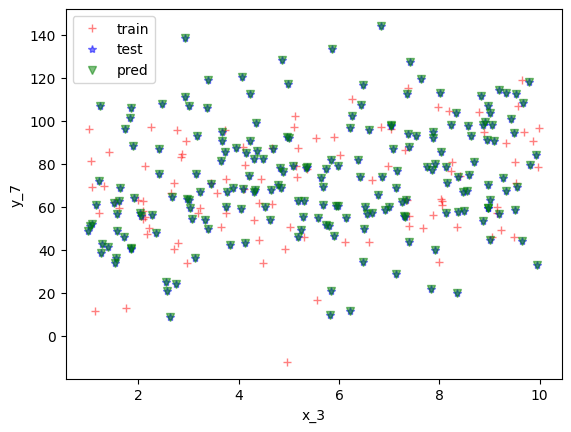

True parameters: w_true=[[-1.0885423   0.52916825 -0.77728527 -4.86010683 -1.25057786  0.97281136
   4.49031971  1.82180362 -1.09231825 -3.14245184]
 [-2.84146074 -4.57457687  0.16366553  2.9831297  -3.20149852  1.03344815
  -4.2237183   3.71558905  2.1913156  -0.60696001]
 [ 4.42760725  4.9126862  -2.68551176 -4.8570325  -1.9668619  -3.24789033
   2.44973396  1.42219262 -4.34458387 -4.35530365]
 [-4.9654247  -0.5501239   0.52360471  1.69224192 -2.82139734  2.94263968
  -0.78021959  0.78099804 -2.00522514  0.50077457]
 [-3.00915264 -3.43736035 -4.72259982 -3.36160643  2.24272578 -1.8570271
  -4.58120276  4.06783303 -3.72201116  3.55517208]
 [ 3.10867686  2.65695458  1.84176695  1.10012695  1.00923107  2.71229155
   1.16426299 -4.28160559  2.60383416  4.60949862]
 [ 4.98858073 -4.43673807 -0.15509666  2.94029905  2.54649995  3.25397076
  -0.0891353  -3.43463753 -1.1789168   3.13037321]
 [-2.258519   -2.55475572 -2.34881611  0.16891656 -2.12799394 -0.12816458
   2.83006084  1.99691992  3

In [ ]:
noise_level = 0.01
for i, (num_features, num_targets) in enumerate([(1, 1), (10, 1), (10, 10)]):
    print(f'num_features = {num_features}, num_targets = {num_targets}')
    # generate evaluation dataset
    (x_train, y_train), (x_test, y_test), (w_true, b_true) = generate_evaluation_data(num_features, num_targets, noise_level)

    # Use x_train and y_train as training data to fit your model;
    # then calculate the prediction y_pred for x_test
    w, b = linear_regression_params(x_train, y_train)
    y_pred = linear_regression_predict(w, b, x_test)

    # visualize the results
    i = np.random.choice(num_features) # if there are multiple predictors (features), randomly select one to plot as x
    j = np.random.choice(num_targets) # if there are multiple targets
    ##if num_features == 1 and num_targets == 1:
      ##    plt.xlim(1, 10)  # Adjust x-limits as needed
        ##  plt.ylim(-7, 10) # Adjust y-limits as needed




    #train data
    plt.plot(x_train[:, i], y_train[:, j], 'r+', label='train', alpha=0.5)


    #test data
    plt.plot(x_test[:, i], y_test[:, j], 'b*', label='test', alpha=0.5)


    #predicted data
    plt.plot(x_test[:, i], y_pred[:, j], 'gv', label='pred', alpha=0.5)




    plt.xlabel(f'x_{i}')
    plt.ylabel(f'y_{j}')
    plt.legend()
    plt.show()
    # print result summary
    print(f'True parameters: w_true={w_true}, b_true={b_true}')
    print(f'Learned parameters: w={w}, b={b}')
    print(f'The distance between w_true and w: {np.linalg.norm(w_true - w)}')
    print(f'The distance between b_true and b: {np.linalg.norm(b_true - b)}')
    print(f'The distance between y_pred and y_test: {np.linalg.norm(y_test - y_pred)}\n\n')